# XXZ QGP regression experiment

This notebook reproduces the QGP regression plots for the XXZ dataset. The reusable Gaussian-process and shot-noise routines live in `../src/qgp_machinery.jl`; this notebook is intentionally kept as a thin, readable driver for loading data, running the fits, and saving figures.

Expected input files are placed in `../data/`:

- `true_outputs_m2_$(N_QUBITS)q.npy`
- `true_overlaps_m2_$(N_QUBITS)q.npy`
- `circle_true_outputs_m2_$(N_QUBITS)q.npy`
- `circle_true_overlaps_m2_$(N_QUBITS)q.npy`
- optionally, `initial_variables.json` containing `t_start` and `t_stop` for the 2D grid axes.

## 1. Imports and project paths

In [1]:
using LinearAlgebra
using Random
using Statistics

using NPZ
using JSON
using PyPlot
using LaTeXStrings
using Interpolations
using PyCall

# Resolve paths both when the notebook is launched from `notebooks/` and when
# it is launched from the project root.
const HERE = let d = @__DIR__
    isempty(d) ? pwd() : d
end
const PROJECT_ROOT = basename(HERE) == "notebooks" ? dirname(HERE) : HERE
const INPUT_DIR = joinpath(PROJECT_ROOT, "data")
const SRC_DIR = joinpath(PROJECT_ROOT, "src")
const FIGURE_DIR = joinpath(PROJECT_ROOT, "plots")

const GLOBAL_ROOT = dirname(PROJECT_ROOT)
const GLOBAL_CONFIG_DIR = joinpath(GLOBAL_ROOT, "config")

include(joinpath(SRC_DIR, "qgp_machinery.jl"))
using .QuantumGPs

isdir(FIGURE_DIR) || mkpath(FIGURE_DIR)

PyPlot.matplotlib.style.use("default")
PyPlot.matplotlib.style.use(joinpath(GLOBAL_CONFIG_DIR, "unified_plots.mplstyle"))
PyPlot.matplotlib.rcParams["pdf.fonttype"] = 42

const PLOT_ARGS = JSON.parsefile(joinpath(GLOBAL_CONFIG_DIR, "unified_plots.json"))

Dict{String, Any} with 11 entries:
  "gp_mean"               => Dict{String, Any}("label"=>"QGP", "zorder"=>4, "li…
  "classification"        => Dict{String, Any}("xlabel"=>"\$J_1 / J_2\$", "ylab…
  "fig_width_inches_full" => 6.75
  "observations"          => Dict{String, Any}("label"=>"training points", "mar…
  "true_function"         => Dict{String, Any}("label"=>"Ground truth", "dashes…
  "optimization"          => Dict{String, Any}("scatter"=>Dict{String, Any}("li…
  "regression"            => Dict{String, Any}("xlabel"=>"\$t\$", "ylabel"=>"\$…
  "benchmarking"          => Dict{String, Any}("methods"=>Dict{String, Any}("gp…
  "macros"                => Dict{String, Any}("shotsobs"=>"n_{\\mathrm{s}}^{\\…
  "gp_stds"               => Dict{String, Any}("label"=>"__nolegend__", "alpha"…
  "fig_width_inches_half" => 3.375

## 2. Experiment configuration

In [2]:
const N_QUBITS = 100
const MAJORANA_ORDER = 2
const RNG_SEED = 1234
const SAVE_FIGURES = true

# Square-grid experiment.
const GRID_OBSERVATION_SHOTS = Int(1e4)
const GRID_KERNEL_SHOTS = Int(1e4)
const GRID_OBSERVATION_NOISE_MODEL = :iid_equal_mean

# One-dimensional circular cut.
const CIRCLE_OBSERVATION_SHOTS = Int(1e5)
const CIRCLE_KERNEL_SHOTS = Int(1e5)
const CIRCLE_OBSERVATION_NOISE_MODEL = :iid_equal_mean

rng = MersenneTwister(RNG_SEED)

MersenneTwister(1234)

## 3. Shared plotting and experiment helpers

In [3]:
"""
    make_kwargs(dict) -> Dict{Symbol,Any}

Convert a JSON dictionary with string keys into keyword arguments usable by
PyPlot calls.
"""
make_kwargs(dict) = Dict(Symbol(k) => v for (k, v) in dict)

"""
    save_figure(fig, filename; kwargs...)

Save a PyPlot figure under `FIGURE_DIR` when `SAVE_FIGURES` is enabled, and
return the full path. This keeps all generated figures in a single location.
"""
function save_figure(fig, filename; bbox_inches="tight", pad_inches=0.1, transparent=true, dpi=600)
    filepath = joinpath(FIGURE_DIR, filename)
    if SAVE_FIGURES
        fig.savefig(filepath; bbox_inches=bbox_inches, pad_inches=pad_inches, transparent=transparent, dpi=dpi)
        @info "Saved figure" filepath
    end
    return filepath
end

"""
    load_grid_limits(path; default=(-100.0, 100.0)) -> t_start, t_stop

Load grid-axis limits from `initial_variables.json`. If the file is absent,
fall back to a symmetric default range.
"""
function load_grid_limits(path; default=(-100.0, 100.0))
    if isfile(path)
        variables = JSON.parsefile(path)
        return Float64(variables["t_start"]), Float64(variables["t_stop"])
    end

    @warn "Grid metadata not found; using default axis limits." path default
    return default
end

"""
    run_qgp_experiment(true_outputs, exact_kernel; kwargs...) -> NamedTuple

Apply the kernel shot-noise model, sample noisy training observations, and run
QGP regression over all points in the precomputed kernel.
"""
function run_qgp_experiment(
    true_outputs::AbstractVector,
    exact_kernel::AbstractMatrix;
    n::Integer,
    train_idxs::AbstractVector{<:Integer},
    nshots_obs,
    nshots_kernel,
    obs_noise_model::Symbol = :upper_bound,
    psd_method::Symbol = :semicircle,
    rng::AbstractRNG = Random.default_rng(),
)
    support_size = binomial(2n, MAJORANA_ORDER)
    kernel_raw, kernel_vars_raw = add_noise_2_kernel_sum(exact_kernel, support_size, nshots_kernel; rng=rng)

    scale = kernel_scaling_factor(n, MAJORANA_ORDER)
    kernel = kernel_raw .* scale
    kernel_vars = kernel_vars_raw .* scale^2

    obs_vars = [shotvar_sumZ(true_outputs[i], n, nshots_obs; model=obs_noise_model) for i in train_idxs]
    observations = [noisy_sum_Z(true_outputs[i], n, nshots_obs; model=obs_noise_model, rng=rng) for i in train_idxs]

    fit = qgp_fit_predict(
        kernel,
        observations,
        train_idxs;
        obs_σ² = obs_vars,
        ker_σ² = kernel_vars,
        ker_ε = 1e-10,
        psd_method = psd_method,
    )

    return (
        kernel = kernel,
        kernel_variances = kernel_vars,
        train_idxs = collect(train_idxs),
        observations = observations,
        observation_variances = obs_vars,
        observation_stds = sqrt.(obs_vars),
        mean = fit.mean,
        variance = fit.var,
        std = fit.std,
        kernel_reg_shift = fit.kernel_reg_shift,
        posterior = fit.gp_posterior_obj,
    )
end

"""
    training_coordinates(train_idxs, true_outputs, grid_shape, x_axis, y_axis; n)

Convert column-major linear training indices into `(x, y, z)` coordinates for
3D plotting.
"""
function training_coordinates(train_idxs, true_outputs, grid_shape, x_axis, y_axis; n::Integer)
    ny, nx = grid_shape
    xs = Vector{Float64}(undef, length(train_idxs))
    ys = Vector{Float64}(undef, length(train_idxs))
    zs = Vector{Float64}(undef, length(train_idxs))

    for (t, idx) in enumerate(train_idxs)
        iy = ((idx - 1) % ny) + 1
        ix = ((idx - 1) ÷ ny) + 1
        xs[t] = x_axis[ix]
        ys[t] = y_axis[iy]
        zs[t] = true_outputs[idx] / n
    end

    return xs, ys, zs
end

training_coordinates

## 4. Plotting helpers

In [4]:
Line2D = PyPlot.matplotlib.lines.Line2D
Path = PyPlot.matplotlib.path.Path
Patch = PyPlot.matplotlib.patches.Rectangle
HandlerBase = PyPlot.matplotlib.legend_handler.HandlerBase
cm = PyPlot.matplotlib.cm

const GRID_MARKER = let
    verts = [
        (-0.33, -1.0), (-0.33,  1.0),
        ( 0.33, -1.0), ( 0.33,  1.0),
        (-1.0, -0.33), ( 1.0, -0.33),
        (-1.0,  0.33), ( 1.0,  0.33),
    ]
    codes = [
        Path.MOVETO, Path.LINETO,
        Path.MOVETO, Path.LINETO,
        Path.MOVETO, Path.LINETO,
        Path.MOVETO, Path.LINETO,
    ]
    Path(verts, codes)
end

@pydef mutable struct CmapStripHandler <: HandlerBase
    function create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans)
        nstrips = 24
        cmap = cm.get_cmap("turbo")
        artists = PyObject[]

        for i in 0:(nstrips - 1)
            x0 = -xdescent + width * i / nstrips
            rect = Patch(
                (x0, -ydescent),
                width / nstrips,
                height;
                facecolor = cmap((i + 0.5) / nstrips),
                edgecolor = "none",
                alpha = 0.55,
            )
            rect.set_transform(trans)
            push!(artists, rect)
        end

        border = Patch(
            (-xdescent, -ydescent),
            width,
            height;
            facecolor = "none",
            edgecolor = "black",
            linewidth = 0.4,
        )
        border.set_transform(trans)
        push!(artists, border)

        return artists
    end
end

"""
    plot_grid_prediction(true_grid, qgp_result; kwargs...) -> fig, ax

Create the 3D square-grid QGP figure: QGP surface, ground-truth wireframe,
training observations, and the circular cut used in the one-dimensional plot.
"""
function plot_grid_prediction(
    true_grid::AbstractMatrix,
    qgp_result;
    n::Integer,
    x_axis,
    y_axis,
    arc_angle_range = range(4π / 6, 5π / 6; length=300),
    arc_radius = 100.0,
    plot_args = PLOT_ARGS,
)
    ny, nx = size(true_grid)

    Z_true = Array(true_grid) ./ n
    Z_gp = reshape(qgp_result.mean, ny, nx) ./ n
    σz_train = Float64.(qgp_result.observation_stds) ./ n

    X = repeat(reshape(collect(x_axis), 1, :), ny, 1)
    Y = repeat(reshape(collect(y_axis), :, 1), 1, nx)
    xs, ys, zs = training_coordinates(qgp_result.train_idxs, vec(true_grid), size(true_grid), x_axis, y_axis; n=n)

    # Circular cut shown on top of the surface.
    x_curve = arc_radius .* cos.(arc_angle_range)
    y_curve = arc_radius .* sin.(arc_angle_range)
    itp = interpolate((collect(y_axis), collect(x_axis)), Z_true, Gridded(Linear()))
    valid = [minimum(x_axis) <= x <= maximum(x_axis) && minimum(y_axis) <= y <= maximum(y_axis)
             for (x, y) in zip(x_curve, y_curve)]
    x_arc = x_curve[valid]
    y_arc = y_curve[valid]
    z_arc = [itp(y, x) for (x, y) in zip(x_arc, y_arc)]

    fig_width = plot_args["fig_width_inches_half"]
    fig = figure(figsize=(fig_width, 2.5), dpi=600)
    ax = fig.add_subplot(111, projection="3d", computed_zorder=false)

    cmap = PyPlot.matplotlib.cm.get_cmap("turbo")
    c_lo, c_hi = extrema(Z_true)
    norm = PyPlot.matplotlib.colors.Normalize(vmin=c_lo, vmax=c_hi)

    ax.plot_surface(
        X,
        Y,
        Z_gp;
        cmap = cmap,
        norm = norm,
        alpha = 0.55,
        edgecolor = "none",
        linewidth = 0.0,
        antialiased = true,
        zorder = 1,
        rasterized = true,
    )

    ax.plot_wireframe(
        X,
        Y,
        Z_true;
        color = "black",
        alpha = 0.55,
        linewidth = 0.2,
        zorder = 2,
    )

    ax.scatter(
        xs,
        ys,
        zs;
        marker = "o",
        linewidths = 0.5,
        s = 8,
        c = "#E69F00",
        edgecolors = "black",
        alpha = 0.8,
        depthshade = false,
        zorder = 20,
    )

    ax.errorbar(
        xs,
        ys,
        zs;
        zerr = σz_train,
        fmt = "none",
        ecolor = "#E69F00",
        elinewidth = 1.0,
        alpha = 1.0,
        zorder = 19,
    )

    ax.plot(
        x_arc,
        y_arc,
        z_arc;
        color = "#000000",
        linewidth = 0.75,
        linestyle = "-",
        zorder = 10,
    )

    label_pad = -10
    tick_pad = -5
    tick_pad_z = -5

    ax.set_xlabel(L"h_1", labelpad=label_pad)
    ax.set_ylabel(L"h_2", labelpad=label_pad)
    ax.set_zlabel("")
    ax.text2D(
        -0.10,
        0.50,
        L"\frac{1}{n}\sum_k \langle Z_k \rangle" * "\n";
        transform = ax.transAxes,
        rotation = 90,
        va = "center",
        ha = "center",
    )

    ax.tick_params(axis="x", pad=tick_pad)
    ax.tick_params(axis="y", pad=tick_pad)
    ax.tick_params(axis="z", pad=tick_pad_z)

    for lbl in ax.get_zticklabels()
        lbl.set_horizontalalignment("right")
        lbl.set_verticalalignment("center")
    end
    for lbl in ax.get_yticklabels()
        lbl.set_horizontalalignment("right")
        lbl.set_verticalalignment("center")
    end

    ax.grid(false)
    ax.xaxis.pane.set_visible(false)
    ax.yaxis.pane.set_visible(false)
    ax.zaxis.pane.set_visible(false)
    ax.set_facecolor("none")
    ax.margins(x=0, y=0, z=0)

    zmin = min(minimum(Z_true), minimum(Z_gp))
    zmax = max(maximum(Z_true), maximum(Z_gp))
    ax.set_zlim(zmin - 0.05, zmax + 0.05)

    ax.set_xticks([-100, -50, 0, 50, 100])
    ax.set_yticks([-100, -50, 0, 50, 100])
    ax.view_init(elev=30, azim=30)

    true_proxy = Line2D(
        [0],
        [0];
        linestyle = "none",
        marker = GRID_MARKER,
        markersize = 8,
        markeredgewidth = 0.2,
        markerfacecolor = "none",
        markeredgecolor = "black",
        color = "black",
        label = "Ground truth",
    )

    train_proxy = Line2D(
        [0],
        [0];
        marker = "o",
        linestyle = "none",
        alpha = 0.8,
        markerfacecolor = "#E69F00",
        markeredgecolor = "black",
        markeredgewidth = 0.5,
        label = "$(length(qgp_result.train_idxs)) training point$(length(qgp_result.train_idxs) == 1 ? "" : "s")",
    )

    gp_proxy = Patch((0, 0), 1, 1; facecolor="none", edgecolor="none", label="QGP")

    ax.legend(
        handles = [true_proxy, train_proxy, gp_proxy],
        loc = "lower center",
        bbox_to_anchor = (0.5, 1.02),
        ncol = 3,
        frameon = false,
        columnspacing = 1.2,
        handletextpad = 0.4,
        handler_map = Dict{Any, Any}(gp_proxy => CmapStripHandler()),
    )

    PyPlot.matplotlib.rcParams["savefig.bbox"] = nothing
    fig.subplots_adjust(left=0.12, right=0.98, bottom=0.0, top=0.88)

    return fig, ax
end

"""
    plot_qgp_curve(theta_values, y_true, qgp_result; kwargs...) -> fig, ax

Plot the one-dimensional circular cut: ground truth, QGP mean, one-sigma band,
and noisy training observations.
"""
function plot_qgp_curve(
    theta_values,
    y_true::AbstractVector,
    qgp_result;
    n::Integer,
    panel_title = "",
    plot_args = PLOT_ARGS,
)
    fig_width = plot_args["fig_width_inches_half"]
    fig, ax = PyPlot.subplots(figsize=(fig_width, 2.5), dpi=600)

    μ = qgp_result.mean ./ n
    σ = qgp_result.std ./ n
    y_obs = qgp_result.observations ./ n

    true_line = ax.plot(theta_values, y_true ./ n; make_kwargs(plot_args["true_function"])...)[1]

    obs_kwargs = make_kwargs(plot_args["observations"])
    obs_kwargs[:label] = "$(length(qgp_result.train_idxs)) $(plot_args["observations"]["label"])"
    obs_points = ax.plot(theta_values[qgp_result.train_idxs], y_obs; obs_kwargs...)[1]

    qgp_band = ax.fill_between(theta_values, μ .- σ, μ .+ σ; make_kwargs(plot_args["gp_stds"])...)
    qgp_line = ax.plot(theta_values, μ; make_kwargs(plot_args["gp_mean"])...)[1]

    if !isempty(panel_title)
        ax.set_title(panel_title)
    end

    ax.set_xlabel(L"\theta" * "\n" * L"h_1=100\cos(\theta),\;h_2=100\sin(\theta)")
    ax.set_ylabel(L"\frac{1}{n}\sum_k \langle Z_k \rangle")
    ax.legend([true_line, obs_points, (qgp_line, qgp_band)],
              [true_line.get_label(), obs_points.get_label(), qgp_line.get_label()])

    return fig, ax
end

plot_qgp_curve

## 5. Square-grid QGP experiment

In [5]:
true_outputs_grid = npzread(joinpath(INPUT_DIR, "true_outputs_m2_$(N_QUBITS)q.npy"))
exact_kernel_grid = npzread(joinpath(INPUT_DIR, "true_overlaps_m2_$(N_QUBITS)q.npy"))

true_outputs = vec(true_outputs_grid)

t_start, t_stop = load_grid_limits(joinpath(INPUT_DIR, "initial_variables.json"))
ny, nx = size(true_outputs_grid)
x_axis = collect(range(t_start, stop=t_stop, length=nx))
y_axis = collect(range(t_start, stop=t_stop, length=ny))

# The published figure uses a single corner training point. Keep alternative
# choices here explicit rather than hidden in commented-out exploratory cells.
grid_train_idxs = [1]

grid_result = run_qgp_experiment(
    true_outputs,
    exact_kernel_grid;
    n = N_QUBITS,
    train_idxs = grid_train_idxs,
    nshots_obs = GRID_OBSERVATION_SHOTS,
    nshots_kernel = GRID_KERNEL_SHOTS,
    obs_noise_model = GRID_OBSERVATION_NOISE_MODEL,
    psd_method = :semicircle,
    rng = rng,
)

@info "Grid QGP run complete" ntrain=length(grid_train_idxs) max_abs_error=maximum(abs.(grid_result.mean .- true_outputs)) / N_QUBITS

┌ Info: Grid QGP run complete
│   ntrain = 1
│   max_abs_error = 0.0636024574746645
└ @ Main /Users/kremsgroup/Desktop/provable-scalable-quantum-gaussian-processes/03_XXZ_Model/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:27


sys:1: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
┌ Info: Saved figure
│   filepath = /Users/kremsgroup/Desktop/provable-scalable-quantum-gaussian-processes/03_XXZ_Model/plots/full_mag_n100_1tp.pdf
└ @ Main /Users/kremsgroup/Desktop/provable-scalable-quantum-gaussian-processes/03_XXZ_Model/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W6sZmlsZQ==.jl:19


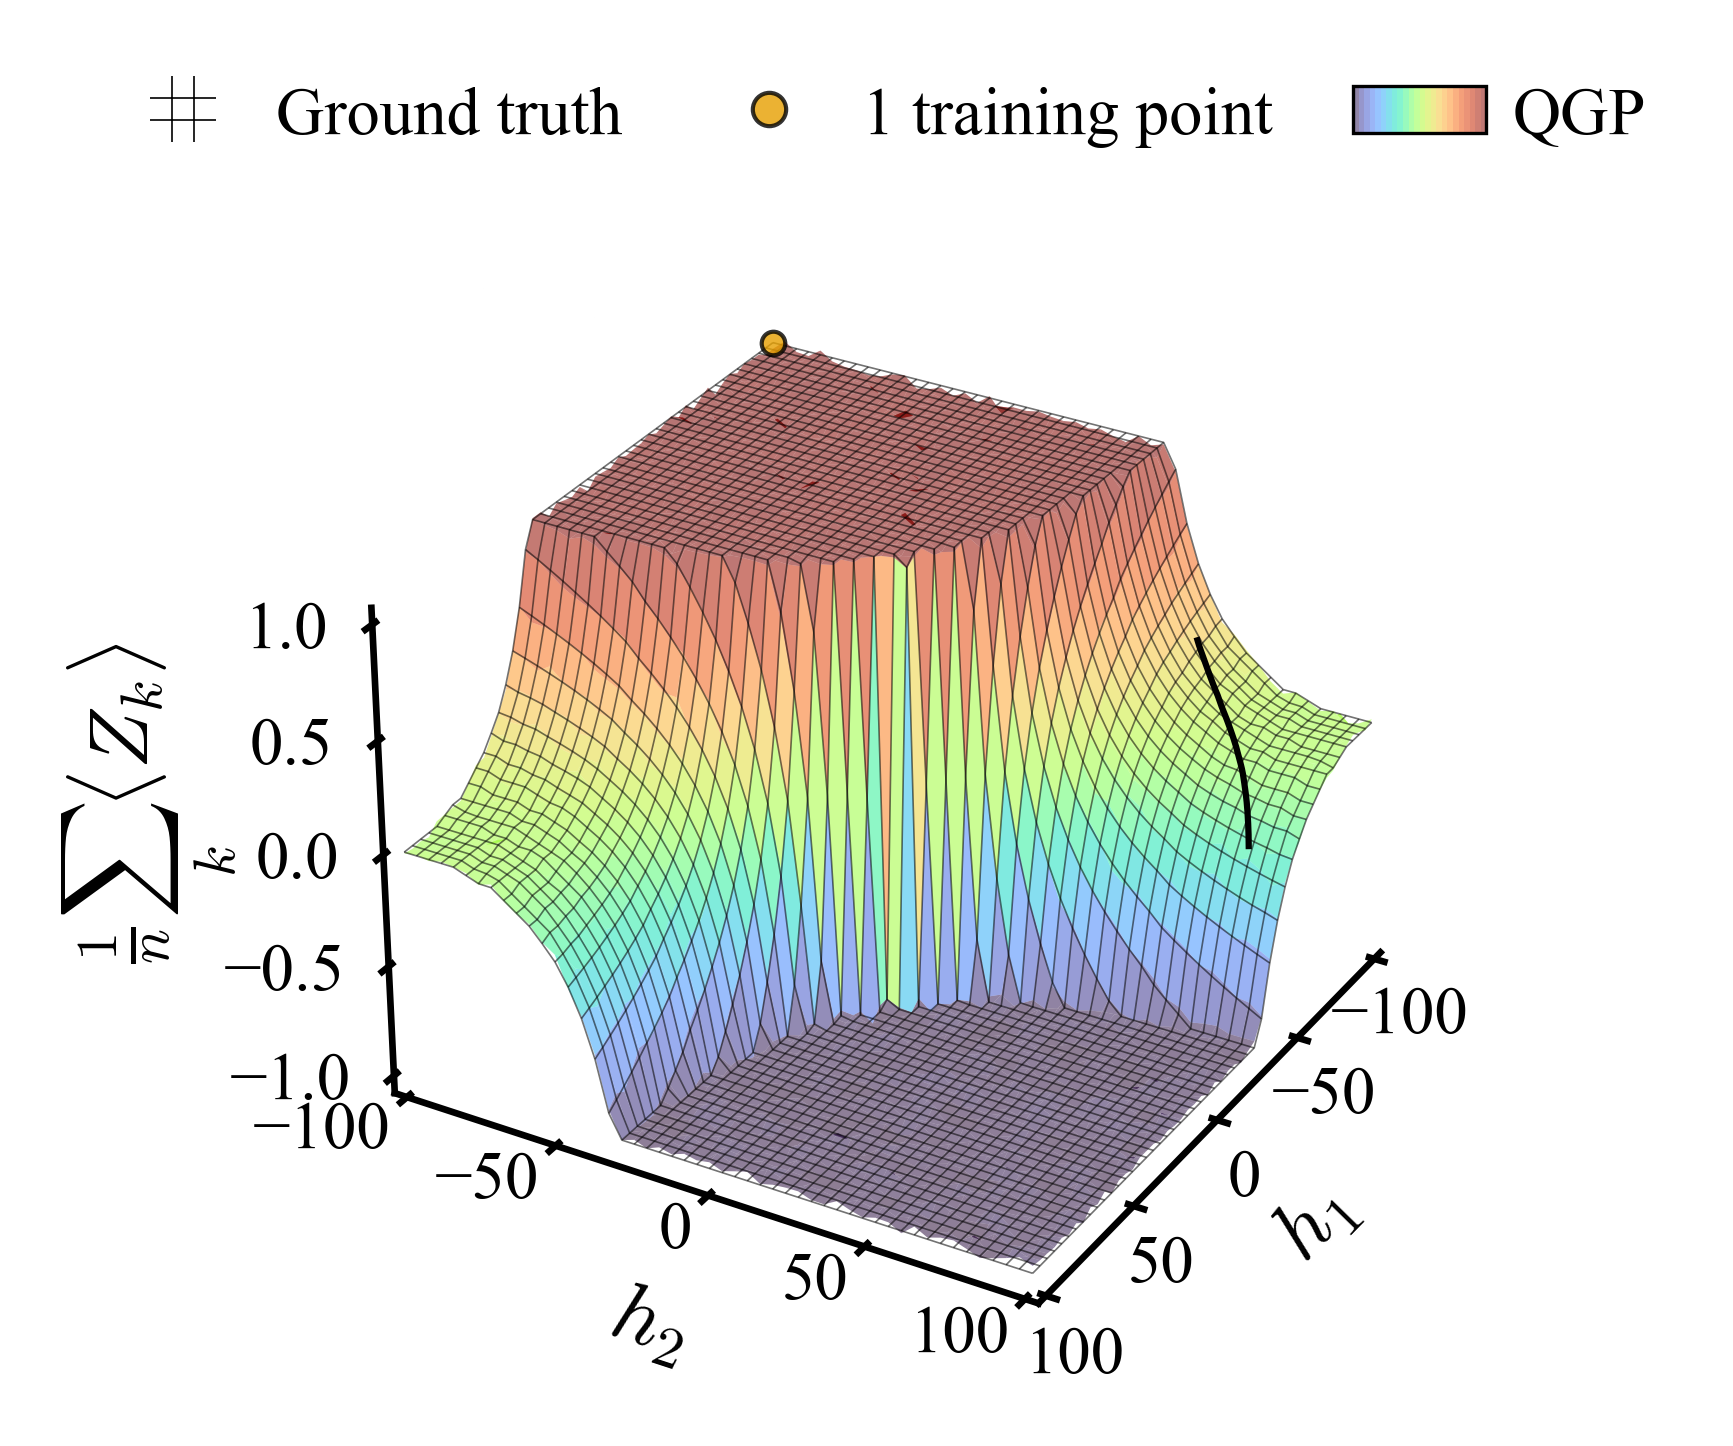

In [6]:
fig_grid, ax_grid = plot_grid_prediction(
    true_outputs_grid,
    grid_result;
    n = N_QUBITS,
    x_axis = x_axis,
    y_axis = y_axis,
)

save_figure(
    fig_grid,
    "full_mag_n$(N_QUBITS)_$(length(grid_train_idxs))tp.pdf";
    bbox_inches = nothing,
    pad_inches = 0.0,
    transparent = true,
    dpi = 600,
)

fig_grid

## 6. Circular-cut QGP experiment

In [7]:
true_outputs_circle = vec(npzread(joinpath(INPUT_DIR, "circle_true_outputs_m2_$(N_QUBITS)q.npy")))
exact_kernel_circle = npzread(joinpath(INPUT_DIR, "circle_true_overlaps_m2_$(N_QUBITS)q.npy"))

theta_values = collect(range(4π / 6, stop=5π / 6, length=length(true_outputs_circle)))
circle_train_idxs = [1, length(true_outputs_circle)]

circle_result = run_qgp_experiment(
    true_outputs_circle,
    exact_kernel_circle;
    n = N_QUBITS,
    train_idxs = circle_train_idxs,
    nshots_obs = CIRCLE_OBSERVATION_SHOTS,
    nshots_kernel = CIRCLE_KERNEL_SHOTS,
    obs_noise_model = CIRCLE_OBSERVATION_NOISE_MODEL,
    psd_method = :semicircle,
    rng = rng,
)

@info "Circular-cut QGP run complete" ntrain=length(circle_train_idxs) max_abs_error=maximum(abs.(circle_result.mean .- true_outputs_circle)) / N_QUBITS

┌ Info: Circular-cut QGP run complete
│   ntrain = 2
│   max_abs_error = 0.021102552878639925
└ @ Main /Users/kremsgroup/Desktop/provable-scalable-quantum-gaussian-processes/03_XXZ_Model/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X16sZmlsZQ==.jl:19


┌ Info: Saved figure
│   filepath = /Users/kremsgroup/Desktop/provable-scalable-quantum-gaussian-processes/03_XXZ_Model/plots/circle_qgp_n100_100000obs_2tp.pdf
└ @ Main /Users/kremsgroup/Desktop/provable-scalable-quantum-gaussian-processes/03_XXZ_Model/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W6sZmlsZQ==.jl:19


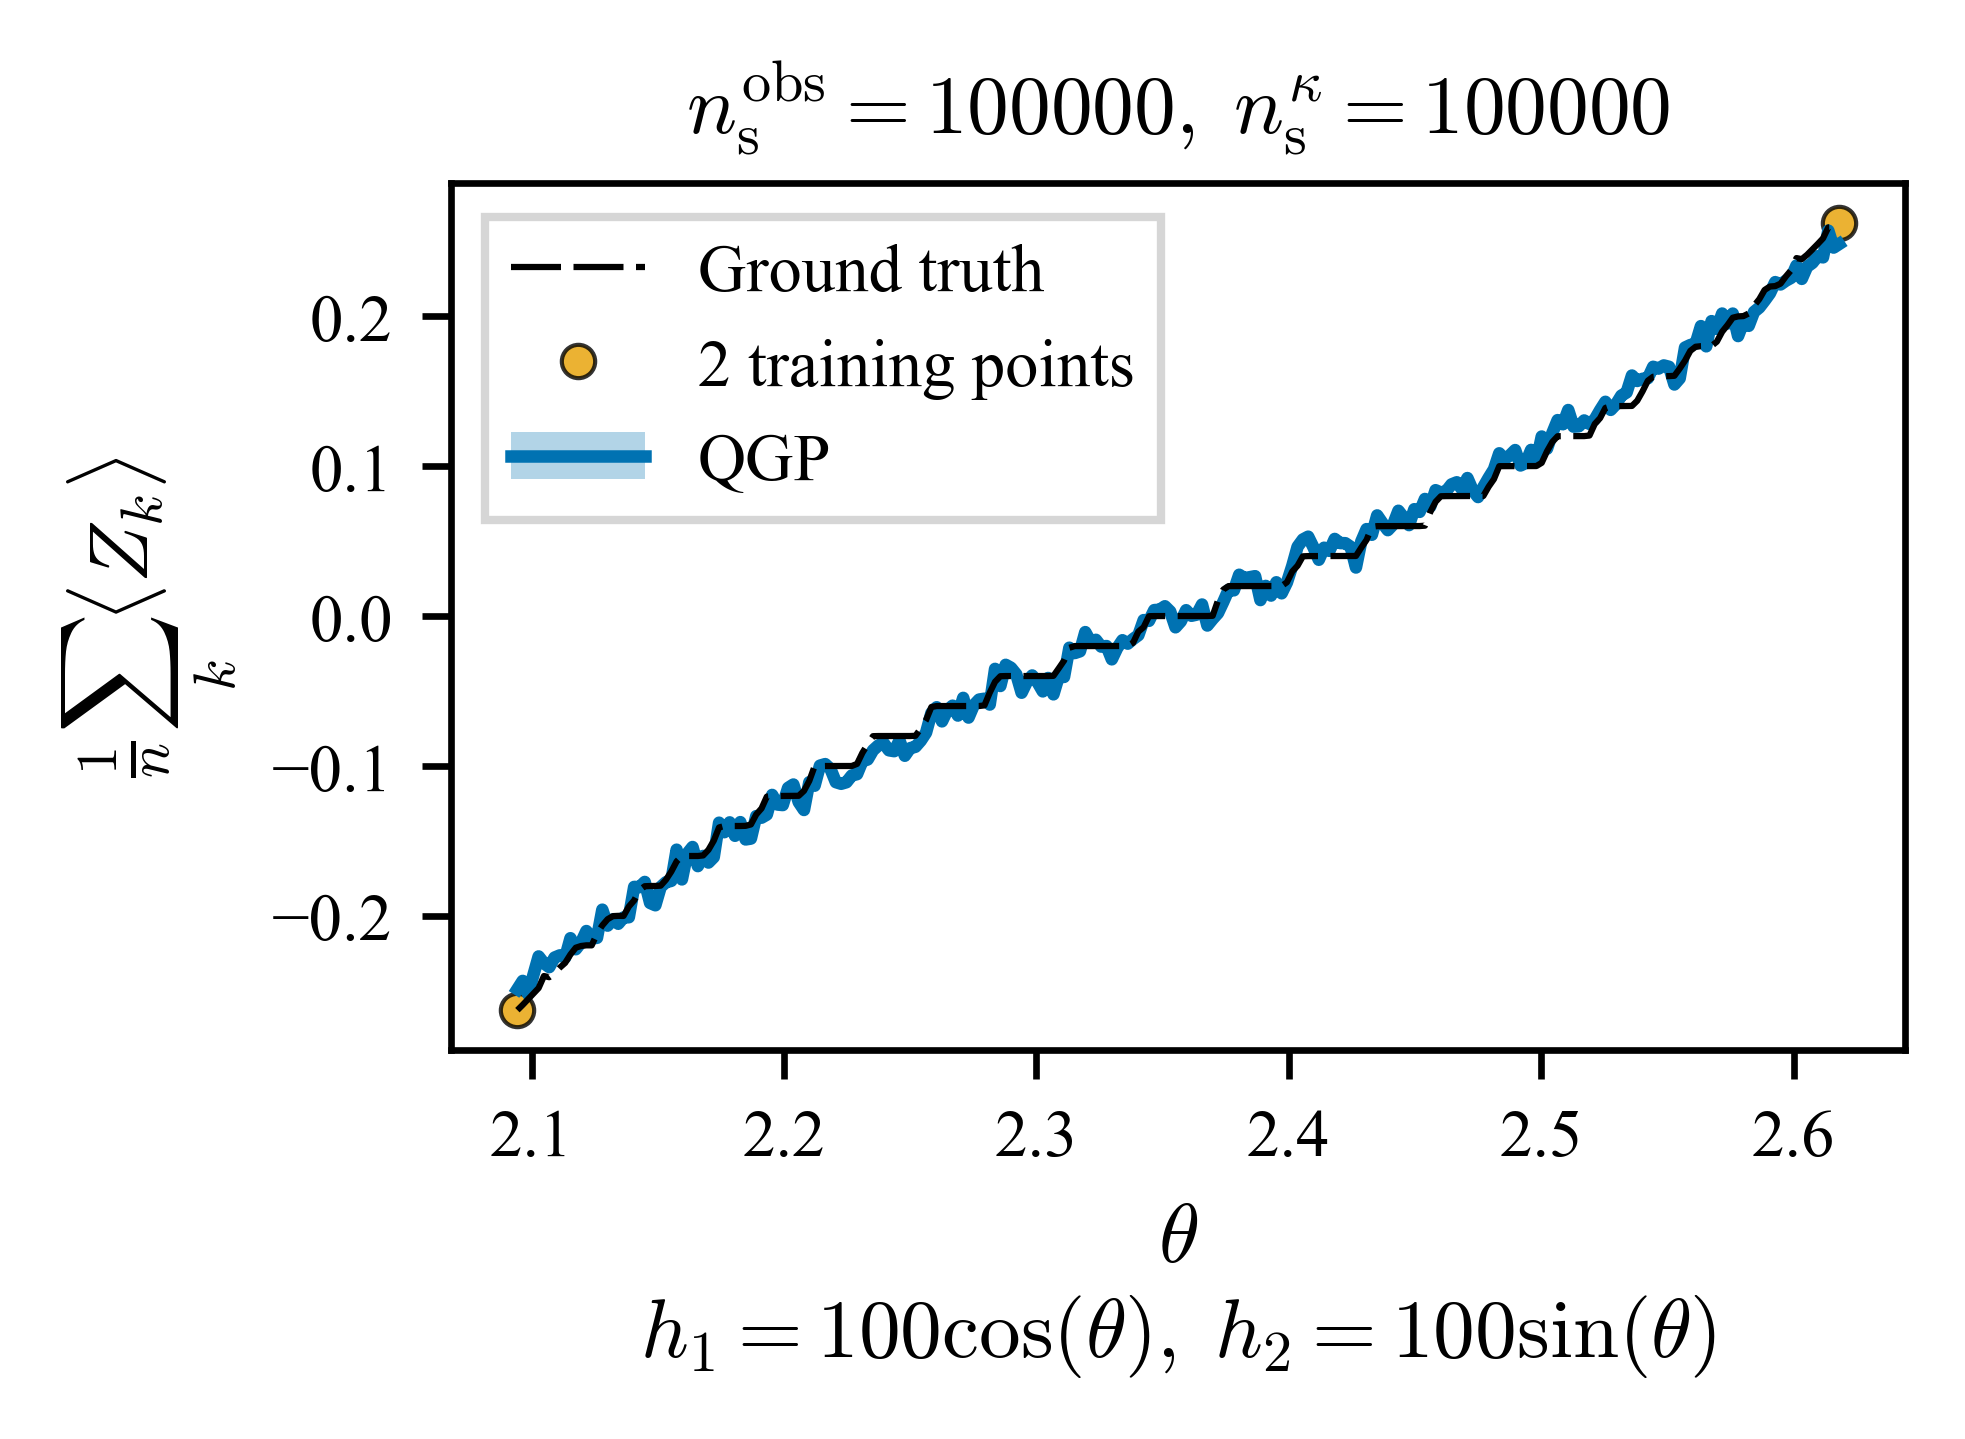

In [8]:
panel_title = latexstring(
    "n_{\\mathrm{s}}^{\\mathrm{obs}}=$(CIRCLE_OBSERVATION_SHOTS),\\;" *
    "n_{\\mathrm{s}}^{\\kappa}=$(CIRCLE_KERNEL_SHOTS)"
)

fig_circle, ax_circle = plot_qgp_curve(
    theta_values,
    true_outputs_circle,
    circle_result;
    n = N_QUBITS,
    panel_title = panel_title,
)

save_figure(
    fig_circle,
    "circle_qgp_n$(N_QUBITS)_$(CIRCLE_OBSERVATION_SHOTS)obs_$(length(circle_train_idxs))tp.pdf";
    bbox_inches = "tight",
    pad_inches = 0.1,
    transparent = true,
    dpi = 600,
)

fig_circle

## 7. Optional diagnostics

In [9]:
grid_diagnostics = (
    training_indices = grid_result.train_idxs,
    observation_stds = grid_result.observation_stds,
    kernel_reg_shift = grid_result.kernel_reg_shift,
    max_abs_error_per_qubit = maximum(abs.(grid_result.mean .- true_outputs)) / N_QUBITS,
)

circle_diagnostics = (
    training_indices = circle_result.train_idxs,
    observation_stds = circle_result.observation_stds,
    kernel_reg_shift = circle_result.kernel_reg_shift,
    max_abs_error_per_qubit = maximum(abs.(circle_result.mean .- true_outputs_circle)) / N_QUBITS,
)

(grid = grid_diagnostics, circle = circle_diagnostics)

(grid = (training_indices = [1], observation_stds = [5.575503985246929e-9], kernel_reg_shift = [0.014106736079665918], max_abs_error_per_qubit = 0.0636024574746645), circle = (training_indices = [1, 250], observation_stds = [0.03051115990331309, 0.03051552053344111], kernel_reg_shift = [0.007239655096880548, 0.007239921211661874], max_abs_error_per_qubit = 0.021102552878639925))